<h3>Happy Customers</h3>

<h4>Notebook 5</h4>

- Re-evaluating my feature selection process with other methods.
- I only really evaluated based on multicolinearity and a small combination of ANOVA F and mutual information scores.
- I should have put more time into considering correlation with the label as well as co linearity, or whether there is any info present.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Bespoke functions:
from model_evaluation import *
from data_prep import *

In [3]:
X, Y = generate_XY(data_path="ACME-HappinessSurvey2020.csv")
X.head(5)

,X1,X2,X3,X4,X5,X6
0,3,3,3,4,2,4
1,3,2,3,5,4,3
2,5,3,3,3,3,5
3,5,4,3,3,3,5
4,5,4,3,3,3,5


In [4]:
Y.head(5)

,Y
0,0
1,0
2,1
3,0
4,0


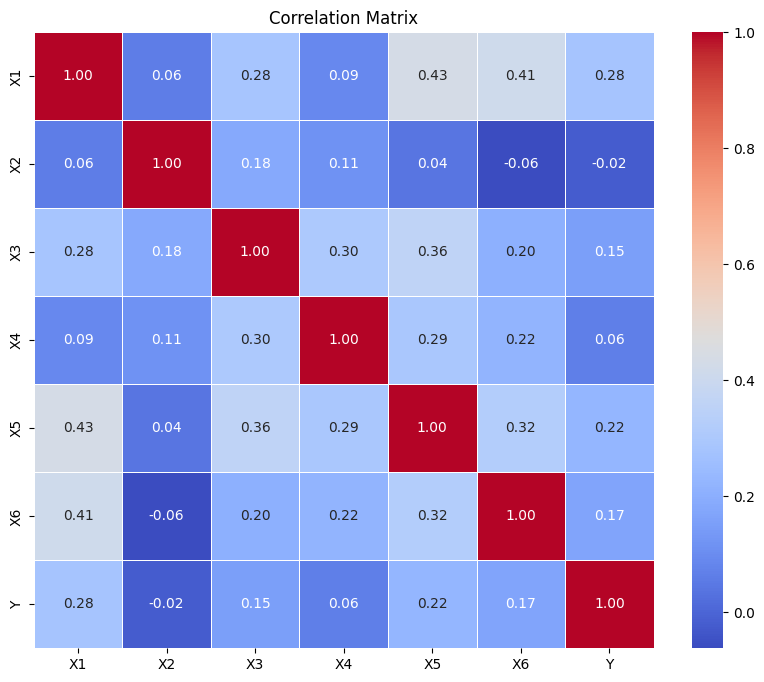

In [5]:
# 1. Correlation Analysis:

# Helps to identify correlation and multicolinearity

data = pd.concat([X,Y], axis=1)
corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5
            )

plt.title("Correlation Matrix")
plt.show()

- Looking here, whilst there appears to be correlated among X3, X5, X1, and X6, it is clear that X2 and X4 have no correlation with Y. Before ignored this and removed X3 and X5 due to signs of colinearity.

In [6]:
# 2. Mutual Information

from sklearn.feature_selection import mutual_info_classif

Y_array = Y["Y"].to_numpy().ravel() # Seems to complain when we pass a df column and not a 1d array for Y...

mi_scores = mutual_info_classif(X, Y_array)
print(mi_scores)

# Put MI scores into a sorted table with relative contribution (%)
mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI Score": mi_scores
}).sort_values("MI Score", ascending=False).reset_index(drop=True)

mi_total = mi_df["MI Score"].sum()
mi_df["Relative Importance (%)"] = (
    (mi_df["MI Score"] / mi_total * 100) if mi_total > 0 else 0
).round(2)

print(mi_df)

[0.1025378  0.00536334 0.         0.         0.05194626 0.06744734]
  Feature  MI Score  Relative Importance (%)
0      X1  0.102538                    45.11
1      X6  0.067447                    29.67
2      X5  0.051946                    22.85
3      X2  0.005363                     2.36
4      X4  0.000000                     0.00
5      X3  0.000000                     0.00


- X2, X4 and X6 show little MI.

In [7]:
# 3. ANOVA F-test:

# Do the mean values of a feature differ significantly between the two target classes?

from sklearn.feature_selection import SelectKBest, f_classif

# Fit selector
af_selector = SelectKBest(score_func=f_classif, k="all")
af_selector.fit(X, Y_array)

# Create results dataframe
anova_results = pd.DataFrame({
    "Feature": X.columns,
    "F_Score": af_selector.scores_,
    "P_Value": af_selector.pvalues_
})

# Sort by importance
anova_results = anova_results.sort_values(
    by="F_Score",
    ascending=False
)

print(anova_results)

  Feature    F_Score   P_Value
0      X1  10.561708  0.001486
4      X5   6.582716  0.011488
5      X6   3.586849  0.060568
2      X3   2.886959  0.091807
3      X4   0.516657  0.473623
1      X2   0.073108  0.787313


- Again, X2 and X4 appear to be the features that should be removed.
- I'm going to remove X2 and X4, then start with Logistic Regression:

<h5>Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

In [9]:
X, Y = generate_XY(data_path="ACME-HappinessSurvey2020.csv",feature_cols=['X1', 'X3', 'X5','X6'])
X_train_scaled, X_test_scaled, Y_train, Y_test = split_scale_data(X,Y, stratify=Y['Y'], test_size=0.2, random_state=13)

model = LogisticRegression(max_iter=1000,random_state=13)


param_grid = [
    {
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "C": [0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    },
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": [0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    },
    {
        "solver": ["saga"],
        "penalty": ["l1", "l2"],
        "C": [0.1, 1, 10, 100],
        "class_weight": [None, "balanced"]
    }
]

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=13
)

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="f1",      # good if classes are imbalanced
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, Y_train)

print("Best parameters:")
print(grid.best_params_)

best_lr = grid.best_estimator_
Y_lr_grid_pred = best_lr.predict(X_test_scaled)
Y_lr_grid_proba = best_lr.predict_proba(X_test_scaled)[:, 1]

lr_grid_eval = evaluate_binary_classifier(Y_test, Y_lr_grid_pred, Y_lr_grid_proba)

Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best parameters:
{'C': 0.1, 'class_weight': None, 'penalty': 'l1', 'solver': 'saga'}

===== Binary Classification Evaluation =====

Accuracy: 0.5385
Balanced Accuracy: 0.5119
Precision: 0.5455
Recall: 0.8571
F1 Score: 0.6667
Matthews Corrcoef: 0.0329
ROC AUC: 0.5714
Log Loss: 0.6848

Confusion Matrix:
[[ 2 10]
 [ 2 12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.17      0.25        12
           1       0.55      0.86      0.67        14

    accuracy                           0.54        26
   macro avg       0.52      0.51      0.46        26
weighted avg       0.52      0.54      0.47        26



c:\Users\cochr\Data Science Projects\Happy Customers\Happy Customers\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\cochr\Data Science Projects\Happy Customers\Happy Customers\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


<h5>SVC

In [13]:
from sklearn.svm import SVC

param_grid = {
    'C': [0.01, 0.1, 0.5, 1.0, 10, 100],
    'gamma': ['scale', 0.01, 0.1],
    'kernel': ['rbf','linear']
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=13
)

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, Y_train)

print(grid.best_params_)
best_svm = grid.best_estimator_

Y_best_pred = best_svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(Y_test, Y_best_pred))
print("F1-Score:", f1_score(Y_test, Y_best_pred))
print(classification_report(Y_test, Y_best_pred))

{'C': 1.0, 'gamma': 0.01, 'kernel': 'rbf'}
Accuracy: 0.5769230769230769
F1-Score: 0.7027027027027027
              precision    recall  f1-score   support

           0       0.67      0.17      0.27        12
           1       0.57      0.93      0.70        14

    accuracy                           0.58        26
   macro avg       0.62      0.55      0.48        26
weighted avg       0.61      0.58      0.50        26



- Looking better. F1 of 70% with high precision and recall.

<h5>KNN

In [16]:
from sklearn.neighbors import KNeighborsClassifier

# Hyperparameter grid
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "p": [1, 2]
}

# CV strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=13)

# Grid search
grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid.fit(X_train_scaled, Y_train)

print("Best params:", grid.best_params_)

# Evaluate tuned model on test set
best_knn = grid.best_estimator_
Y_pred_tuned = best_knn.predict(X_test_scaled)
Y_proba_tuned = best_knn.predict_proba(X_test_scaled)[:, 1]

evaluate_binary_classifier(Y_test, Y_pred_tuned, Y_proba_tuned)

Best params: {'metric': 'manhattan', 'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}

===== Binary Classification Evaluation =====

Accuracy: 0.7308
Balanced Accuracy: 0.7202
Precision: 0.7059
Recall: 0.8571
F1 Score: 0.7742
Matthews Corrcoef: 0.4616
ROC AUC: 0.6667
Log Loss: 0.6690

Confusion Matrix:
[[ 7  5]
 [ 2 12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.58      0.67        12
           1       0.71      0.86      0.77        14

    accuracy                           0.73        26
   macro avg       0.74      0.72      0.72        26
weighted avg       0.74      0.73      0.72        26



{'metrics': {'Accuracy': 0.7307692307692307,
  'Balanced Accuracy': 0.7202380952380952,
  'Precision': 0.7058823529411765,
  'Recall': 0.8571428571428571,
  'F1 Score': 0.7741935483870968,
  'Matthews Corrcoef': 0.4615633996151572,
  'ROC AUC': 0.6666666666666667,
  'Log Loss': 0.6689680256853539},
 'confusion_matrix': array([[ 7,  5],
        [ 2, 12]]),
 'classification_report': '              precision    recall  f1-score   support\n\n           0       0.78      0.58      0.67        12\n           1       0.71      0.86      0.77        14\n\n    accuracy                           0.73        26\n   macro avg       0.74      0.72      0.72        26\nweighted avg       0.74      0.73      0.72        26\n'}

- F1-score at 77% !